In [11]:
import yfinance as yf

ticker = "AAL"

df = yf.download(
    ticker,
    period="10y",
    auto_adjust=False
)

[*********************100%***********************]  1 of 1 completed


In [12]:
df.columns

MultiIndex([('Adj Close', 'AAL'),
            (    'Close', 'AAL'),
            (     'High', 'AAL'),
            (      'Low', 'AAL'),
            (     'Open', 'AAL'),
            (   'Volume', 'AAL')],
           names=['Price', 'Ticker'])

<Axes: title={'center': 'AAL Closing Price History'}, xlabel='Date'>

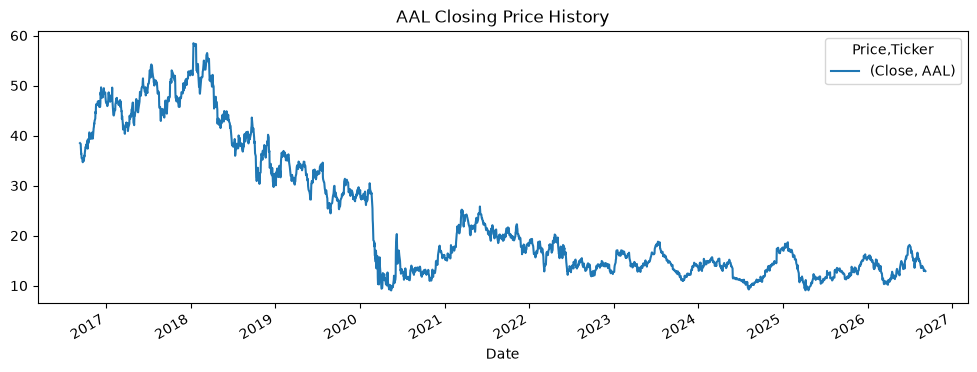

In [13]:
df.shape 
df[['Close']].plot(figsize=(12,4), title=f'{ticker} Closing Price History') 

In [21]:
df[['Close']].values

array([[38.49000168],
       [38.34000015],
       [37.36999893],
       ...,
       [12.97000027],
       [13.13000011],
       [12.90999985]], shape=(2512, 1))

In [22]:
close_prices=df[['Close']].values

In [26]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(close_prices)

In [31]:
train_size=int(len(scaled_data)*0.8)

In [32]:
train_data=scaled_data[:train_size]
test_data=scaled_data[train_size:]

In [37]:
import numpy as np 
  
def create_sequences(data, window_size=60): 
    X, y = [], [] 
    for i in range(window_size, len(data)): 
        X.append(data[i-window_size:i, 0])   
        y.append(data[i, 0])
    return np.array(X), np.array(y) 

In [38]:
WINDOW_SIZE = 60 
X_train, y_train = create_sequences(train_data, WINDOW_SIZE) 
X_test, y_test = create_sequences(test_data, WINDOW_SIZE)

In [39]:
X_train.shape

(1949, 60)

In [40]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1) 
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [42]:
model=Sequential([
    LSTM(50, return_sequences=True, input_shape=(WINDOW_SIZE,1)),
    Dropout(0.5),
    LSTM(50, return_sequences=False),
    Dropout(0.5),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\burha\anaconda3\envs\dl\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history=model.fit(X_train,y_train, validation_data=(X_test,y_test), batch_size=32, epochs=50, verbose=1)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0248 - val_loss: 4.9850e-04
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0064 - val_loss: 5.2874e-04
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0053 - val_loss: 4.7788e-04
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0051 - val_loss: 8.2805e-04
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0043 - val_loss: 4.8733e-04
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0034 - val_loss: 3.9951e-04
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0040 - val_loss: 7.4393e-04
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0035 - val_loss: 6.0522e-04
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0032 - val_loss: 3.9246e-04
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0030 - val_loss: 4.2918e-04
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0026 - val_loss: 4.9432e-04
Epoch 12/50
61/61 

In [45]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred_scaled=model.predict(X_test)
y_pred=scaler.inverse_transform(y_pred_scaled)
y_test_actual=scaler.inverse_transform(y_test.reshape(-1,1))

rmse=np.sqrt(mean_squared_error(y_test_actual,y_pred))
mae=mean_absolute_error(y_test_actual,y_pred)

print(rmse, mae)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
0.7266337871762272 0.5514882714161754


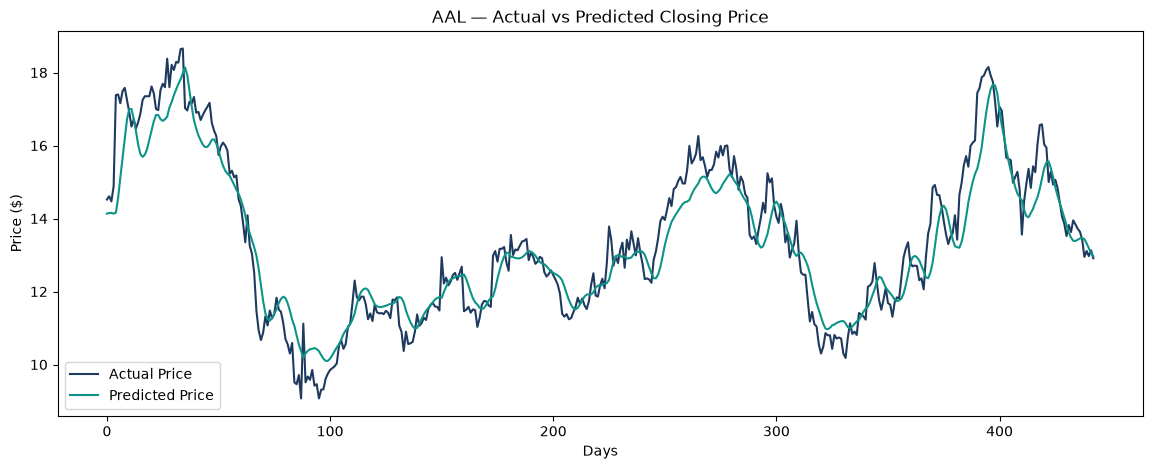

In [46]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14,5)) 
plt.plot(y_test_actual, label='Actual Price', color='#1E3A5F') 
plt.plot(y_pred, label='Predicted Price', color='#0D9488') 
plt.title(f'{ticker} — Actual vs Predicted Closing Price') 
plt.xlabel('Days') 
plt.ylabel('Price ($)') 
plt.legend() 
plt.show() 

In [47]:
model.save('stock_lstm_model.keras') 
  
import joblib 
joblib.dump(scaler, 'stock_scaler.pkl') 
joblib.dump(WINDOW_SIZE, 'stock_window_size.pkl') 

['stock_window_size.pkl']